In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import dill

from datasets import load_dataset,load_from_disk
from sklearn.model_selection import GroupShuffleSplit

from src.preprocessing import *
from src.utils import tech_aliases

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:

# dataset = load_dataset("cnamuangtoun/resume-job-description-fit")
dataset=load_from_disk("../data/raw/resume-job-description-fit")

In [9]:
# dataset.save_to_disk("../data/raw/resume-job-description-fit")

In [6]:
hf_train_df=dataset['train'].to_pandas()
hf_test_df=dataset['test'].to_pandas()

In [7]:
hf_train_df.head()

,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit


In [8]:
hf_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6241 entries, 0 to 6240
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   resume_text           6241 non-null   object
 1   job_description_text  6241 non-null   object
 2   label                 6241 non-null   object
dtypes: object(3)
memory usage: 146.4+ KB


In [10]:
hf_train_df=hf_train_df.drop_duplicates()
hf_test_df=hf_test_df.drop_duplicates()

In [11]:
hf_train_df['job_description_text'].duplicated().sum()

np.int64(5960)

label
No Fit           3142
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Class %:
label
No Fit           50.352564
Potential Fit    24.935897
Good Fit         24.711538
Name: proportion, dtype: float64


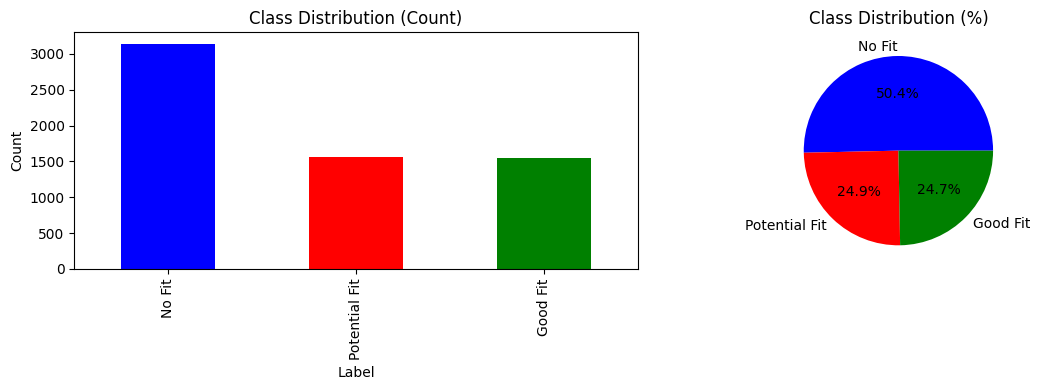


Imbalance Ratio: 2.04x


In [12]:
print(hf_train_df['label'].value_counts())
print("\nClass %:")
print(hf_train_df['label'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hf_train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['blue','red','green'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

hf_train_df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',colors=['blue','red','green'])
axes[1].set_title('Class Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

counts = hf_train_df['label'].value_counts()
ratio = counts.max() / counts.min()
print(f"\nImbalance Ratio: {ratio:.2f}x")

In [13]:
group_size=hf_train_df.groupby('job_description_text').size()

print(group_size.describe())
print("-"*50)
print("Groups with 1 sample:", (group_size == 1).sum())
print("Groups with 2 samples:", (group_size == 2).sum())
print("Groups with 3+ samples:", (group_size >= 3).sum())

count    280.000000
mean      22.285714
std       20.704193
min        1.000000
25%        7.000000
50%       14.500000
75%       29.250000
max      111.000000
dtype: float64
--------------------------------------------------
Groups with 1 sample: 3
Groups with 2 samples: 3
Groups with 3+ samples: 274


In [14]:
hf_train_df['resume_len'] = hf_train_df['resume_text'].apply(lambda x: len(x.split()))
hf_train_df['jd_len'] = hf_train_df['job_description_text'].apply(lambda x: len(x.split()))

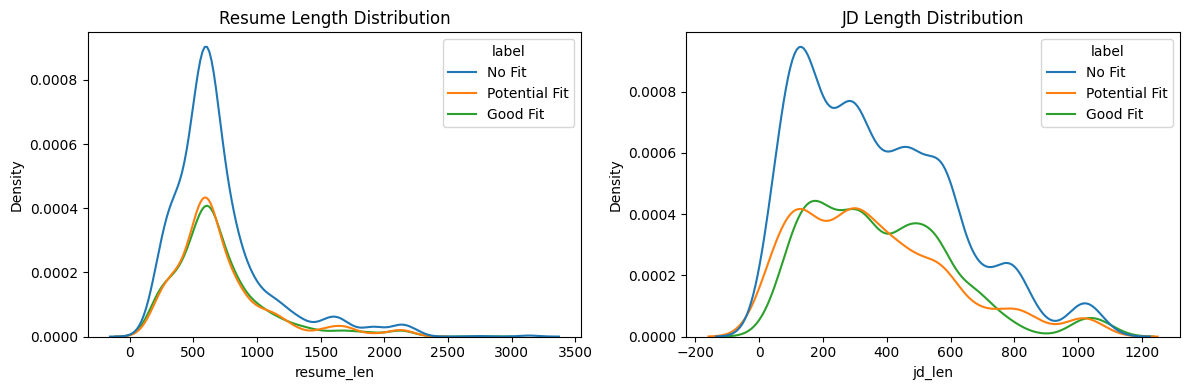

In [15]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

sns.kdeplot(data=hf_train_df,x='resume_len',hue='label',ax=axes[0])
axes[0].set_title('Resume Length Distribution')

sns.kdeplot(data=hf_train_df,x='jd_len',hue='label',ax=axes[1])
axes[1].set_title('JD Length Distribution')

plt.tight_layout()
plt.show()

In [16]:
hf_train_df.groupby('label')[['resume_len', 'jd_len']].mean()

,resume_len,jd_len
label,,
Good Fit,704.920882,384.646563
No Fit,707.776575,370.370146
Potential Fit,711.572622,360.785347


In [17]:
hf_train_df.drop(columns=['resume_len', 'jd_len'], inplace=True)

In [18]:
hf_train_df['resume_exp']=hf_train_df['resume_text'].apply(lambda x:extract_experience(x))
hf_train_df['jd_exp']=hf_train_df['job_description_text'].apply(lambda x:extract_experience(x))

hf_test_df['resume_exp']=hf_test_df['resume_text'].apply(lambda x:extract_experience(x))
hf_test_df['jd_exp']=hf_test_df['job_description_text'].apply(lambda x:extract_experience(x))



In [19]:
hf_train_df[['resume_exp','jd_exp']].head()

,resume_exp,jd_exp
0,0.0,9.0
1,0.0,3.0
2,0.0,6.0
3,8.0,0.0
4,5.0,5.0


In [20]:
zero_resume_exp=hf_train_df[hf_train_df['resume_exp']==0]
print(len(zero_resume_exp))

3549


In [21]:
zero_sample=zero_resume_exp['resume_text'].head(5)
for i,text in enumerate(zero_sample):
  print(f" Sample {i+1}:")
  print(text[:400])
  print()

 Sample 1:
SummaryHighly motivated Sales Associate with extensive customer service and sales experience. Outgoing sales professional with track record of driving increased sales, improving buying experience and elevating company profile with target market.
Highlights-Soft Skills: Public Speaking, Public Relations, Team Building, Project Management, Procedure writing, Staff Supervision and Management, Ability

 Sample 2:
Professional SummaryCurrently working with Caterpillar as an contract employee Active in several NPI and CPI projects Provide technical for CAT facilities worldwide 24-hours a day Willing to travel to meet job requirements Familiar with Power Distribution Systems, NETA, NFPA 70E, and OHSA electrical standards Graduating in December 2014 with a Master's Degree in Industrial Management Excellent com

 Sample 3:
SummaryI started my construction career in June of 2017 in Jacksonville, Florida as an Electrical Apprentice working full time and attending the Jacksonville Elect

In [22]:
zero_jd_exp=hf_train_df[hf_train_df['jd_exp']==0]
print(len(zero_jd_exp))

1455


In [23]:
def clean_text(text):
    text = text.lower()

    # Remove URLs first (before special char removal breaks them)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove phone numbers (10+ digits)
    text = re.sub(r'\b\d{10,}\b', ' ', text)

    # Remove markdown markers but KEEP content inside
    text = re.sub(r'\*+|#+', ' ', text)          # ** ## markers
    text = re.sub(r'_{2,}', ' ', text)            # __ underline markdown

    # Remove brackets but KEEP content inside (years/skills valuable)
    text = re.sub(r'[\[\]()]', ' ', text)

    # Remove page numbers
    text = re.sub(r'page \d+', ' ', text)
    
    # if model_type=="tfidf":
    #     # Remove special characters except spaces/./+/#
    #     text = re.sub(r'[^a-z0-9\s\+\#\.]', ' ', text)
        
    #     # Remove numbers
    #     text = re.sub(r'\d+', ' ', text)

    # Remove extra whitespace — always LAST
    # text = re.sub(r'\s+', ' ', text).strip()

    return text


In [24]:
hf_train_df['resume_text']=hf_train_df['resume_text'].apply(lambda x:clean_text(x))
hf_train_df['job_description_text']=hf_train_df['job_description_text'].apply(lambda x:clean_text(x))


hf_test_df['resume_text']=hf_test_df['resume_text'].apply(lambda x:clean_text(x))
hf_test_df['job_description_text']=hf_test_df['job_description_text'].apply(lambda x:clean_text(x))

In [25]:
label_map = {
    "No Fit": 0,
    "Potential Fit": 1,
    "Good Fit": 2
}

hf_train_df['label'] = hf_train_df['label'].map(label_map)
hf_test_df['label'] = hf_test_df['label'].map(label_map)

In [26]:
gss = GroupShuffleSplit(test_size=0.2,random_state=42)

train_idx,val_idx = next(gss.split(hf_train_df,groups=hf_train_df['job_description_text']))

train_df=hf_train_df.iloc[train_idx]
val_df=hf_train_df.iloc[val_idx]

In [27]:
dill.dump(hf_train_df,open('../data/cleaned/clean_train_df.dill','wb'))

dill.dump(val_df,open('../data/cleaned/clean_val_df.dill','wb'))

dill.dump(hf_test_df,open('../data/cleaned/clean_test_df.dill','wb'))

In [28]:
skills=pd.read_csv('../data/skills/raw/JobsDatasetProcessed.csv')

In [29]:
skills.head()

,ID,Query,Job Title,Description,IT Skills,Soft Skills,Education,Experience,Token Usage
0,3859,Artificial Intelligence,Collaborative Manipulation Roboticist,"Location: Schlumberger-Doll Research, Cambridg...","Collaborative Manipulation, Artificial Intelli...","Problem-solving, Organizational skills, Commun...",NaN,These skills are related to experience.,562
1,3764,Artificial Intelligence,Software Engineer - Innovation Lab,About DENSO DENSO is one of the largest global...,"Software Development, Infotainment Systems, Au...","Creativity, Collaboration, Problem-solving, Ad...",NaN,NaN,616
2,3597,Artificial Intelligence,"Director, Standards & Strategy","As a Director of Strategy & Strategy at Xperi,...","Audio/video codec, Media streaming and storage...","Participation in international standards, cons...","Skills Related to Education:, Undergraduate de...","Skills Related to Experience:, Audio/video cod...",549
3,3746,Artificial Intelligence,Business Strategy Consultant,If you have a strategic mindset and expertise ...,"Mobility technological trends expertise, Busin...","Strategic mindset, Thought leadership, Communi...",NaN,NaN,613
4,3872,Artificial Intelligence,Regular Full-Time,Mission Who We Are Founded and continuously le...,"Test planning, Bug tracking tools, Automation ...","Team player, Entrepreneurial mindset, Problem-...",NaN,NaN,1051


In [30]:
skills.duplicated().sum()

np.int64(0)

In [31]:
skill_set=extract_skills_from_row(skills,"IT Skills")

In [34]:
all_skills=[key for key in tech_aliases.keys()]
all_skills.extend(skill_set)
all_skills=set(all_skills)

In [39]:
list(all_skills)[:5]

['wcs',
 'intrusion detection systems',
 'trend analysis',
 'employee relations',
 'power point)']

In [40]:
dill.dump(all_skills,open('../data/skills/processed/all_skills.pkl','wb'))
